In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ЭТАП 1: Анализ данных (EDA)
Общая загрузка


In [136]:
#1.Загрузить house.csv, вывести 10 строк.
df = pd.read_csv('house.csv')
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [137]:
#2.Посмотреть .info() и .shape.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [138]:
df.shape

(1460, 81)

In [139]:
df.size

118260

In [140]:
#3.Вывести список колонок и их типы.
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [141]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [142]:
#4.Удалить все неиспользуемые признаки (оставить только нужные 7 + SalePrice).
df = df[['GrLivArea', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'FullBath',
    'OverallQual', 'Neighborhood', 'SalePrice']]

In [143]:
df

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,Neighborhood,SalePrice
0,1710,2003,2,856,2,7,CollgCr,208500
1,1262,1976,2,1262,2,6,Veenker,181500
2,1786,2001,2,920,2,7,CollgCr,223500
3,1717,1915,3,756,1,7,Crawfor,140000
4,2198,2000,3,1145,2,8,NoRidge,250000
...,...,...,...,...,...,...,...,...
1455,1647,1999,2,953,2,6,Gilbert,175000
1456,2073,1978,2,1542,2,6,NWAmes,210000
1457,2340,1941,1,1152,2,7,Crawfor,266500
1458,1078,1950,1,1078,1,5,NAmes,142125


In [144]:
#5.Сохранить облегчённый датасет в отдельный CSV (data_clean.csv).
df.to_csv('data_clean.csv', index=False)

Pandas практика (исследование)

In [145]:
#6.Сколько уникальных районов (Neighborhood)?
df['Neighborhood'].unique()

array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
       'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
       'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
       'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
       'Blueste'], dtype=object)

In [146]:
count_neighbor = df['Neighborhood'].nunique()
print(f'Количество уникальных районов (Neighborhood){count_neighbor}')

Количество уникальных районов (Neighborhood)25


In [147]:
#7.Средняя цена по району — топ 5 дорогих районов.
df.groupby('Neighborhood')['SalePrice'].mean().round().sort_values(ascending=False).head(5)

,SalePrice
Neighborhood,
NoRidge,335295.0
NridgHt,316271.0
StoneBr,310499.0
Timber,242247.0
Veenker,238773.0


In [148]:
#8.Сколько домов было построено после 2000 года?
count = (df['YearBuilt'] > 2000).sum()
print(f'Количество домов было построено после 2000 = {count}')

Количество домов было построено после 2000 = 364


In [149]:
df[df['YearBuilt'] > 2000]

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,Neighborhood,SalePrice
0,1710,2003,2,856,2,7,CollgCr,208500
2,1786,2001,2,920,2,7,CollgCr,223500
6,1694,2004,2,1686,2,8,Somerst,307000
11,2324,2005,3,1175,3,9,NridgHt,345000
13,1494,2006,3,1494,2,7,CollgCr,279500
...,...,...,...,...,...,...,...,...
1444,1422,2004,2,1422,2,7,CollgCr,179600
1451,1578,2008,3,1573,2,8,Somerst,287090
1452,1072,2005,2,547,1,5,Edwards,145000
1453,1140,2006,0,1140,1,5,Mitchel,84500


In [150]:
#9.Средняя жилая площадь (GrLivArea) по уровню качества (OverallQual).
df.groupby('OverallQual')['GrLivArea'].mean().round()

,GrLivArea
OverallQual,
1,619.0
2,573.0
3,1119.0
4,1107.0
5,1251.0
6,1466.0
7,1704.0
8,1948.0
9,2078.0


In [151]:
#10.Есть ли дома с нулевым подвалом? Посчитать долю таких домов.
d =(df['TotalBsmtSF'] == 0).sum()
d


np.int64(37)

In [152]:
df[df['TotalBsmtSF'] == 0]

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,Neighborhood,SalePrice
17,1296,1967,2,0,2,4,Sawyer,90000
39,1152,1955,0,0,2,4,Edwards,82000
90,1040,1950,2,0,1,4,NAmes,109900
102,1535,1979,2,0,2,5,SawyerW,118964
156,1040,1950,2,0,1,5,NAmes,109500
182,1340,1957,1,0,1,5,Edwards,120000
259,882,1956,1,0,1,5,OldTown,97000
342,1040,1949,2,0,2,3,NAmes,87500
362,1922,2003,2,0,3,7,Edwards,198500
371,1588,1959,2,0,2,4,ClearCr,134432


In [153]:
(d * 100 / 1460).round(2)

np.float64(2.53)

In [154]:
#11.Группировка по GarageCars и средняя цена.
df.groupby('GarageCars')['SalePrice'].mean().round()

,SalePrice
GarageCars,
0,103317.0
1,128117.0
2,183852.0
3,309636.0
4,192656.0


In [155]:
#12.Сколько домов имеют 2+ ванных комнаты (FullBath)?
(df['FullBath'] > 2).sum()

np.int64(33)

In [156]:
 #13.Район с наибольшим количеством домов.
df['Neighborhood'].value_counts().head(1)

,count
Neighborhood,
NAmes,225


In [157]:
#14.Корреляция GrLivArea, TotalBsmtSF, OverallQual, GarageCars с SalePrice.
df.corr(numeric_only=True)

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,SalePrice
GrLivArea,1.000000,0.199010,0.467247,0.454868,0.630012,0.593007,0.708624
YearBuilt,0.199010,1.000000,0.537850,0.391452,0.468271,0.572323,0.522897
GarageCars,0.467247,0.537850,1.000000,0.434585,0.469672,0.600671,0.640409
TotalBsmtSF,0.454868,0.391452,0.434585,1.000000,0.323722,0.537808,0.613581
FullBath,0.630012,0.468271,0.469672,0.323722,1.000000,0.550600,0.560664
OverallQual,0.593007,0.572323,0.600671,0.537808,0.550600,1.000000,0.790982
SalePrice,0.708624,0.522897,0.640409,0.613581,0.560664,0.790982,1.000000


In [158]:
#15.Построить рейтинг районов по средней цене и сохранить в CSV.
rating_neibor = df.groupby('Neighborhood')['SalePrice'].mean().round().sort_values(ascending=False)
rating_neibor.to_csv('rating', index=False)

Homework

Визуализация (Matplotlib & Seaborn)

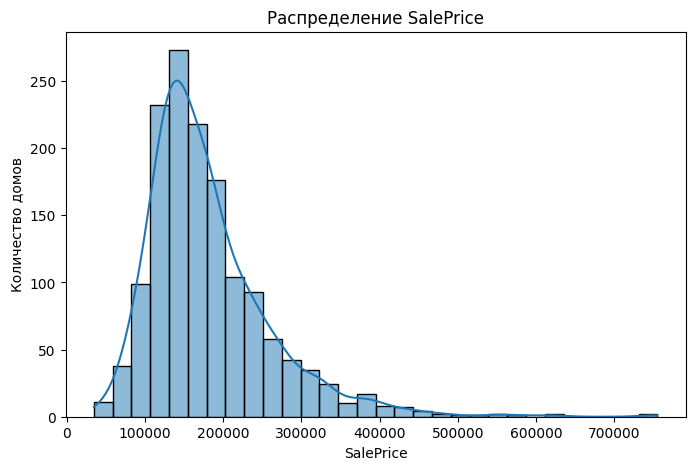

In [159]:
#20.Построить гистограмму SalePrice + распределение (Seaborn distplot).
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title('Распределение SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Количество домов')
plt.show()

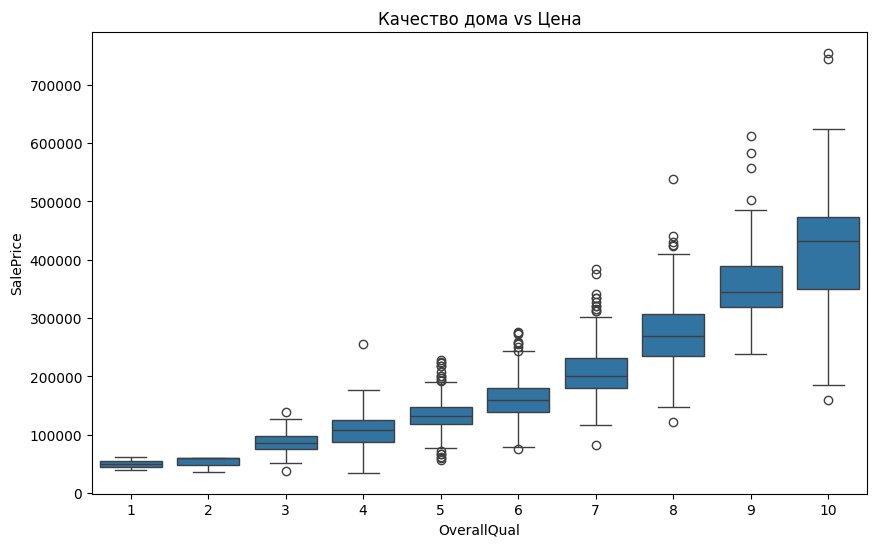

In [160]:
#21.Построить boxplot: OverallQual vs SalePrice.
plt.figure(figsize=(10,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Качество дома vs Цена')
plt.show()

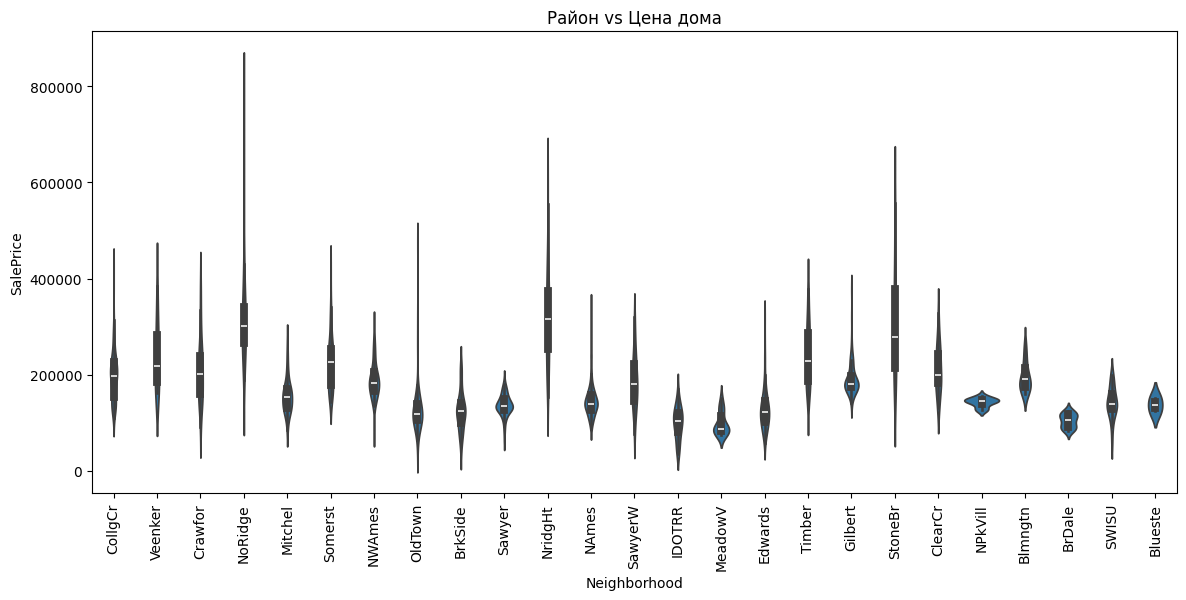

In [161]:
#22.Построить violinplot: Neighborhood vs SalePrice.
plt.figure(figsize=(14,6))
sns.violinplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.title('Район vs Цена дома')
plt.show()

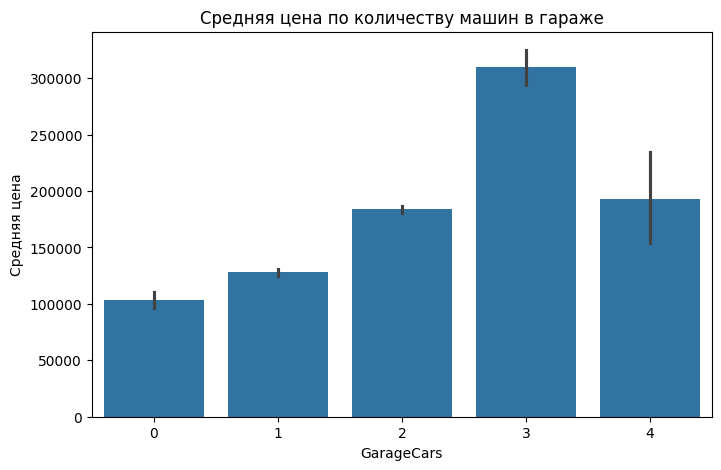

In [162]:
#25.Построить barplot: средняя цена по GarageCars.
plt.figure(figsize=(8,5))
sns.barplot(x='GarageCars', y='SalePrice', data=df, estimator='mean')
plt.title('Средняя цена по количеству машин в гараже')
plt.ylabel('Средняя цена')
plt.show()

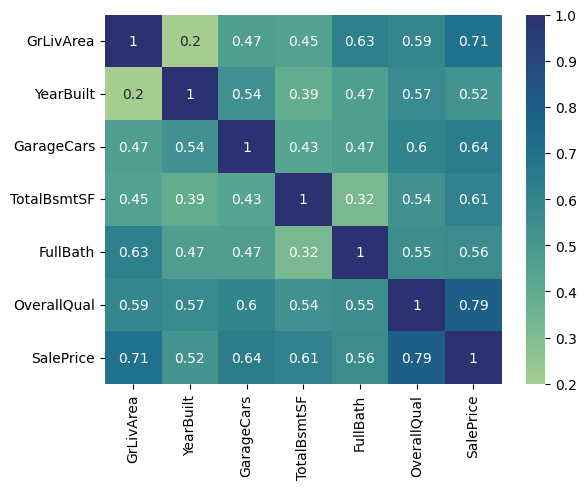

In [163]:
#23.Построить heatmap корреляции между 6 числовыми признаками.
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest')
plt.show()

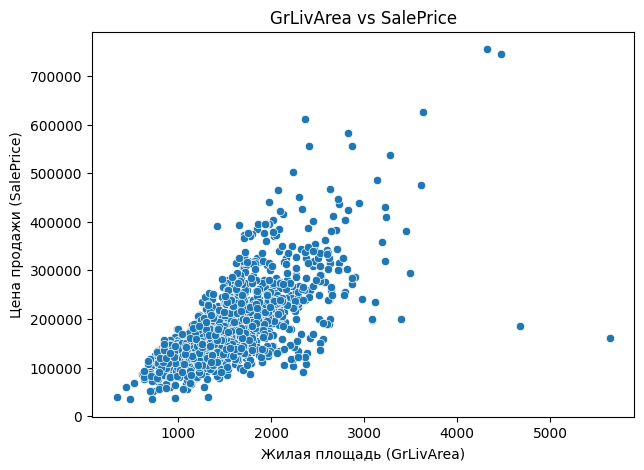

In [164]:
#24.	Построить scatterplot:
#•	GrLivArea vs SalePrice
#•	TotalBsmtSF vs SalePrice
#•	YearBuilt vs SalePrice

#•	GrLivArea vs SalePrice
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.xlabel("Жилая площадь (GrLivArea)")
plt.ylabel("Цена продажи (SalePrice)")
plt.show()

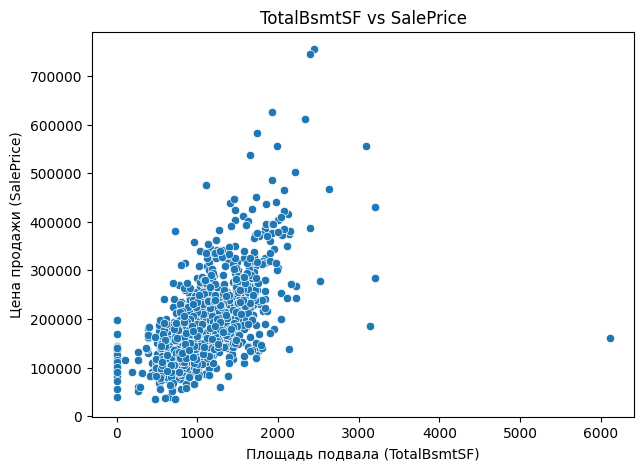

In [165]:
#•TotalBsmtSF vs SalePrice
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="TotalBsmtSF", y="SalePrice")
plt.title("TotalBsmtSF vs SalePrice")
plt.xlabel("Площадь подвала (TotalBsmtSF)")
plt.ylabel("Цена продажи (SalePrice)")
plt.show()

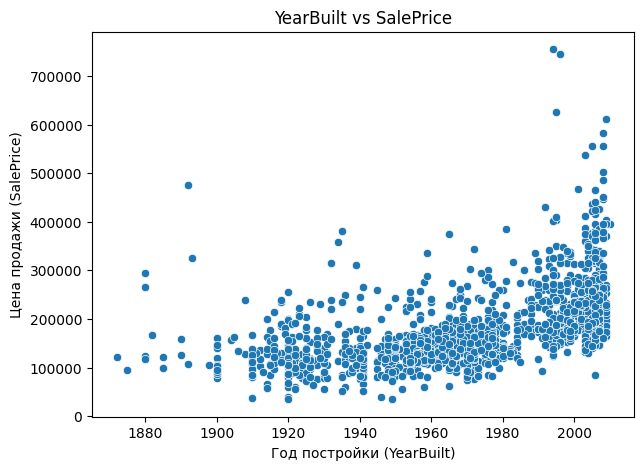

In [166]:
#•	YearBuilt vs SalePrice
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="YearBuilt", y="SalePrice")
plt.title("YearBuilt vs SalePrice")
plt.xlabel("Год постройки (YearBuilt)")
plt.ylabel("Цена продажи (SalePrice)")
plt.show()

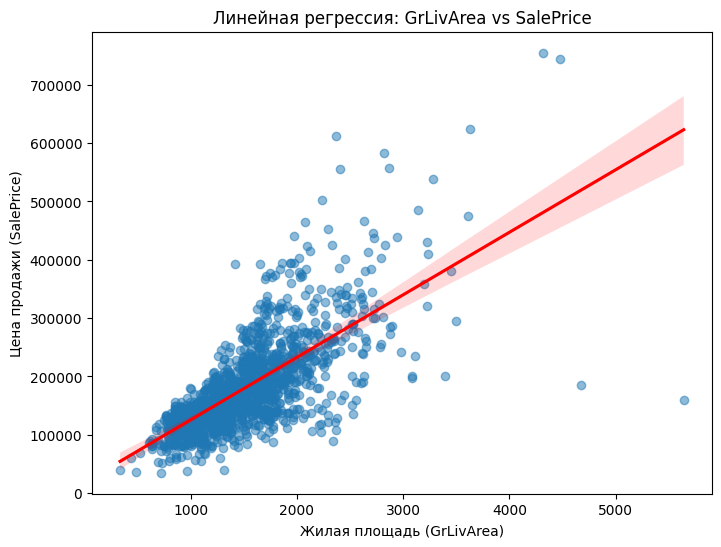

In [167]:
#26.Построить линейную регрессию regplot для GrLivArea vs SalePrice.
plt.figure(figsize=(8,6))
sns.regplot(
    x="GrLivArea",
    y="SalePrice",
    data=df,
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Линейная регрессия: GrLivArea vs SalePrice")
plt.xlabel("Жилая площадь (GrLivArea)")
plt.ylabel("Цена продажи (SalePrice)")

plt.show()

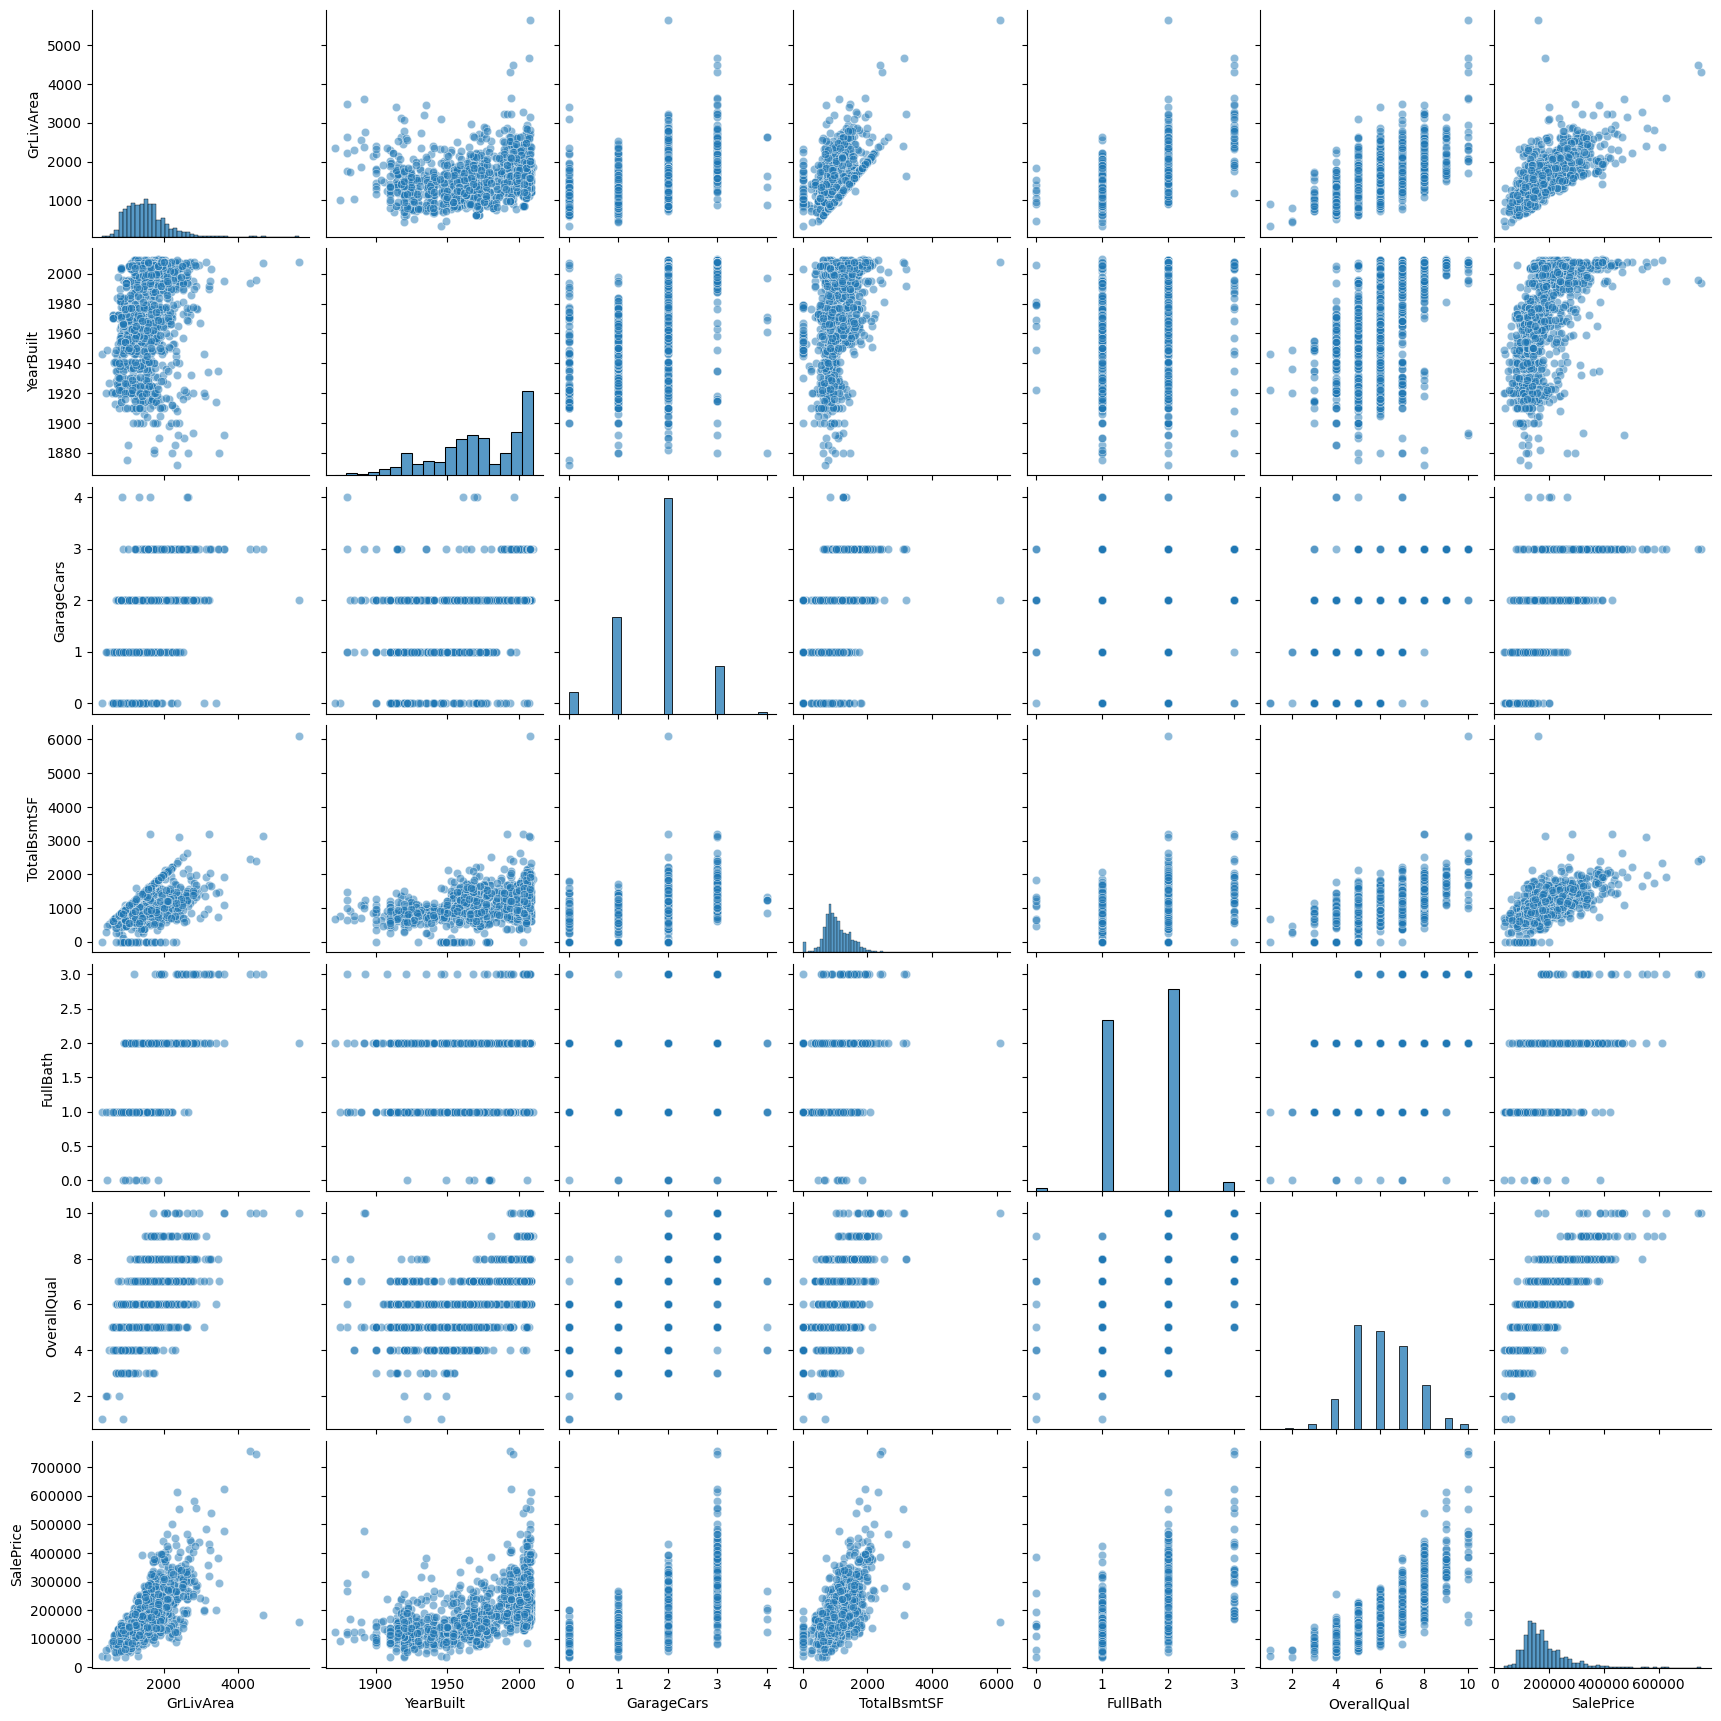

In [168]:
#27.Построить pairplot по всем числовым признакам.
num_df = df.select_dtypes(include=['number'])
sns.pairplot(
    num_df,
    diag_kind="hist",
    plot_kws={"alpha":0.5}
)

plt.show()

ЭТАП 2: Предобработка данных

In [169]:
#28.Обработать пропущенные значения (если есть).
df.isnull().sum()

,0
GrLivArea,0
YearBuilt,0
GarageCars,0
TotalBsmtSF,0
FullBath,0
OverallQual,0
Neighborhood,0
SalePrice,0


In [170]:
#29.Преобразовать Neighborhood в числовой (one-hot или LabelEncoder).
df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)

In [171]:
df.shape

(1460, 31)

In [172]:
df.head()

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,2003,2,856,2,7,208500,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1262,1976,2,1262,2,6,181500,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1786,2001,2,920,2,7,223500,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1717,1915,3,756,1,7,140000,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2198,2000,3,1145,2,8,250000,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [173]:
#30.Нормализовать числовые признаки (MinMaxScaler или StandardScaler).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns=['SalePrice'], axis=1))

In [174]:
df.drop(columns=['SalePrice']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   GrLivArea             1460 non-null   int64
 1   YearBuilt             1460 non-null   int64
 2   GarageCars            1460 non-null   int64
 3   TotalBsmtSF           1460 non-null   int64
 4   FullBath              1460 non-null   int64
 5   OverallQual           1460 non-null   int64
 6   Neighborhood_Blueste  1460 non-null   bool 
 7   Neighborhood_BrDale   1460 non-null   bool 
 8   Neighborhood_BrkSide  1460 non-null   bool 
 9   Neighborhood_ClearCr  1460 non-null   bool 
 10  Neighborhood_CollgCr  1460 non-null   bool 
 11  Neighborhood_Crawfor  1460 non-null   bool 
 12  Neighborhood_Edwards  1460 non-null   bool 
 13  Neighborhood_Gilbert  1460 non-null   bool 
 14  Neighborhood_IDOTRR   1460 non-null   bool 
 15  Neighborhood_MeadowV  1460 non-null   bool 
 16  Neighb

In [175]:
scaled_data

array([[ 0.37033344,  1.05099379,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.48251191,  0.15673371,  0.31172464, ..., -0.13199092,
        -0.16347148, 11.47725023],
       [ 0.51501256,  0.9847523 ,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       ...,
       [ 1.56964722, -1.00249232, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.83278768, -0.70440562, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.49393395, -0.20759447, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888]])

In [176]:
#32.Разделить данные на X и y, где y = SalePrice.
X = scaled_data
y = df['SalePrice']

In [177]:
#33.Разбить данные на train/test (train_test_split, 80/20).
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [178]:
X_train.shape

(1168, 30)

ЭТАП 3: Обучение модели (Linear Regression)

In [179]:
#34.Построить модель LinearRegression() из sklearn.linear_model.
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [180]:
#36.Сделать предсказания на тесте.
model_predict = model.predict(X_test)

In [181]:
#37.Посчитать метрики:•	MAE, MSE, RMSE, R²
from sklearn.metrics import r2_score
r2_score(y_test, model_predict)

0.8267380266474198

In [182]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Homework: NumPy задачи

In [183]:
#16.Вычислить стандартное отклонение и медиану GrLivArea, TotalBsmtSF.
GrLivArea = df['GrLivArea']
TotalBsmtSF = df['TotalBsmtSF']
std_gr = np.std(GrLivArea, ddof=1)
std_bs = np.std(TotalBsmtSF, ddof=1)
med_gr = np.median(GrLivArea)
med_bs = np.median(TotalBsmtSF)

print("GrLivArea  -> std:", std_gr, " median:", med_gr)
print("TotalBsmtSF -> std:", std_bs, " median:", med_bs)

GrLivArea  -> std: 525.4803834232027  median: 1464.0
TotalBsmtSF -> std: 438.7053244594705  median: 991.5


In [184]:
#17.Нормализовать GrLivArea с помощью z-score (вручную через NumPy).
GrLivArea = df['GrLivArea'].values
mean_gr = np.mean(GrLivArea)
std_gr  = np.std(GrLivArea, ddof=1)
threshold = mean_gr + 1.5 * std_gr
big_houses = GrLivArea > threshold

print("Количество домов:", np.sum(big_houses))
print("Площади:", GrLivArea[big_houses][:10])

Количество домов: 106
Площади: [2324 2376 2452 2945 2473 2417 2696 2320 3222 2462]


In [185]:
#18.Найти квартиры с площадью выше +1.5σ от среднего.
GrLivArea = df['GrLivArea'].values
mean_gr = np.mean(GrLivArea)
std_gr  = np.std(GrLivArea, ddof=1)
threshold = mean_gr + 1.5 * std_gr
big_houses_mask = GrLivArea > threshold
count = np.sum(big_houses_mask)

print("Порог:", threshold)
print("Количество домов:", count)
print("Площади:", GrLivArea[big_houses_mask][:10])

Порог: 2303.684273764941
Количество домов: 106
Площади: [2324 2376 2452 2945 2473 2417 2696 2320 3222 2462]


In [186]:
#19.Проверить, сколько домов находится в диапазоне ±1σ от средней цены.
SalePrice = df['SalePrice'].values
mean_price = np.mean(SalePrice)
std_price  = np.std(SalePrice, ddof=1)
low  = mean_price - std_price
high = mean_price + std_price
in_range = (SalePrice >= low) & (SalePrice <= high)
count = np.sum(in_range)
percent = np.mean(in_range) * 100

print("Диапазон:", low, "—", high)
print("Количество домов:", count)
print("Процент:", percent, "%")

Диапазон: 101478.69300752433 — 260363.69877329757
Количество домов: 1145
Процент: 78.42465753424658 %
